In [1]:
import astropy.units as u
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.time import Time
from matplotlib import patches
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

In [30]:
target = '3I/ATLAS'
sector = 92
cadence = 200/60 # TESS cadence in min

In [31]:
btjd0 = 2457000
mpc1st = Time("2025-05-21T22:40:14.704", format="isot", scale="utc")
discovery_date = Time("2025-07-01T05:15:11.21", format="isot", scale="utc")

In [ ]:
lc1 = pd.read_csv("../data/2025/3i_s0092_2-3_lc_v2_ephemcorr.csv", index_col=0)
lc2 = pd.read_csv("../data/2025/3i_s0092_1-2_lc_v2_ephemcorr.csv", index_col=0)
lc = pd.concat([lc1, lc2], axis=0).sort_values("time_tdb").reset_index(drop=True)
lc = lc.rename(columns={"bkg_flux": "bkg_ap_flux"})
lc

,time_tdb,time_e,time_win,ap_flux,ap_flux_err,npix_detect,time_utc_sc,time_utc_geo,nframes,sector,...,prf_flux_err,bkg_prf_flux,bkg_prf_flux_std,bkg_prf_flux_m,bkg_prf_flux_p,v_mag,ra_ephem,dec_ephem,ra_model,dec_model
0,2.460804e+06,0.520886,2.083541,0.649546,0.111609,3.0,2.460804e+06,2.460804e+06,901,92,...,0.177161,0.055397,0.170850,-0.042589,0.156056,19.596467,288.145016,-18.704941,288.145069,-18.704944
1,2.460806e+06,0.520884,2.083533,0.322561,0.103565,1.0,2.460806e+06,2.460806e+06,901,92,...,0.171941,-0.006866,0.165429,-0.173558,0.128967,19.534868,287.859421,-18.691421,287.859481,-18.691423
2,2.460808e+06,0.520881,2.083525,0.519286,0.101167,2.0,2.460808e+06,2.460808e+06,901,92,...,0.164686,-0.033984,0.161786,-0.103362,0.077662,19.473426,287.545615,-18.682061,287.545682,-18.682062
3,2.460810e+06,0.520879,2.298814,0.547405,0.104522,1.0,2.460810e+06,2.460810e+06,901,92,...,0.180184,-0.051704,0.172008,-0.194469,0.073754,19.404286,287.174324,-18.678788,287.174399,-18.678787
4,2.460813e+06,0.520878,2.083511,0.935511,0.108468,4.0,2.460813e+06,2.460813e+06,901,92,...,0.186554,0.024049,0.173242,-0.132184,0.196057,19.341742,286.818249,-18.682879,286.818330,-18.682877
5,2.460817e+06,0.409758,1.421420,0.988996,0.197480,2.0,2.460817e+06,2.460817e+06,521,92,...,0.254452,-0.102361,0.270673,-0.209727,0.085765,19.209173,286.044842,-18.704882,286.046366,-18.701533
6,2.460818e+06,0.300952,1.203807,1.364862,0.177696,4.0,2.460818e+06,2.460818e+06,521,92,...,0.213432,-0.035540,0.216112,-0.206502,0.086179,19.171682,285.803729,-18.701706,285.804541,-18.698417
7,2.460819e+06,0.300951,1.203803,1.571130,0.176947,4.0,2.460819e+06,2.460819e+06,521,92,...,0.224233,-0.057190,0.214592,-0.175533,0.052607,19.133663,285.546765,-18.697126,285.547358,-18.694111
8,2.460820e+06,0.300950,1.203799,1.166398,0.177062,2.0,2.460820e+06,2.460820e+06,521,92,...,0.217324,0.102196,0.215405,-0.120792,0.217238,19.095503,285.277882,-18.693694,285.278603,-18.691089
9,2.460822e+06,0.300949,1.203795,1.316469,0.181940,4.0,2.460822e+06,2.460822e+06,521,92,...,0.228459,0.033016,0.220304,-0.151891,0.243732,19.058012,284.998927,-18.692039,284.999986,-18.689904


In [72]:
lc.columns

Index(['time_tdb', 'time_e', 'time_win', 'ap_flux', 'ap_flux_err',
       'npix_detect', 'time_utc_sc', 'time_utc_geo', 'nframes', 'sector',
       'camera', 'ccd', 'ap_flux_lo5', 'ap_flux_hi5', 'ap_flux_lo10',
       'ap_flux_hi10', 'bkg_ap_flux', 'bkg_ap_flux_std', 'bkg_ap_flux_m',
       'bkg_ap_flux_p', 'prf_flux', 'prf_flux_err', 'bkg_prf_flux',
       'bkg_prf_flux_std', 'bkg_prf_flux_m', 'bkg_prf_flux_p', 'v_mag',
       'ra_ephem', 'dec_ephem', 'ra_model', 'dec_model'],
      dtype='object')

In [73]:
lc["ap_flux"] = [0.463,
0.383,
0.598,
0.541,
1.012,
1.003,
1.333,
1.529,
1.171,
1.333,
2.147,
2.686,
2.618,
2.569,
2.417,]

lc["ap_flux_err"] = [0.111,
 0.103,
 0.100,
 0.104,
 0.107,
 0.198,
 0.178,
 0.177,
 0.177,
 0.182,
 0.174,
 0.188,
 0.209,
 0.195,
 0.252,]

In [74]:
TESSmag_zero_point = 20.44
TESSmag_zero_point_err = 0.05

lc["ap_mag"] = -2.5 * np.log10(lc.ap_flux) + TESSmag_zero_point
lc["ap_mag_err"] = np.sqrt(
    (TESSmag_zero_point_err) ** 2
    + ((2.5 / np.log(10)) * (lc.ap_flux_err / lc.ap_flux)) ** 2
)
lc["ap_lim_mag"] = -2.5 * np.log10(2*np.abs(lc.bkg_ap_flux_std)) + TESSmag_zero_point

lc["prf_mag"] = -2.5 * np.log10(lc.prf_flux) + TESSmag_zero_point
lc["prf_mag_err"] = np.sqrt(
    (TESSmag_zero_point_err) ** 2
    + ((2.5 / np.log(10)) * (lc.prf_flux_err / lc.prf_flux)) ** 2
)
lc["prf_lim_mag"] = -2.5 * np.log10(2*np.abs(lc.bkg_prf_flux_std)) + TESSmag_zero_point

In [75]:
lc["prf_mag_p"] = np.abs(-2.5 * np.log10(lc.prf_flux + lc.prf_flux_err) + 20.44 - lc.prf_mag)
lc["prf_mag_m"] = np.abs(-2.5 * np.log10(lc.prf_flux - lc.prf_flux_err) + 20.44 - lc.prf_mag)
lc["ap_mag_p"] = np.abs(-2.5 * np.log10(lc.ap_flux + lc.ap_flux_err) + 20.44 - lc.ap_mag)
lc["ap_mag_m"] = np.abs(-2.5 * np.log10(lc.ap_flux - lc.ap_flux_err) + 20.44 - lc.ap_mag)

# TESS LC plot

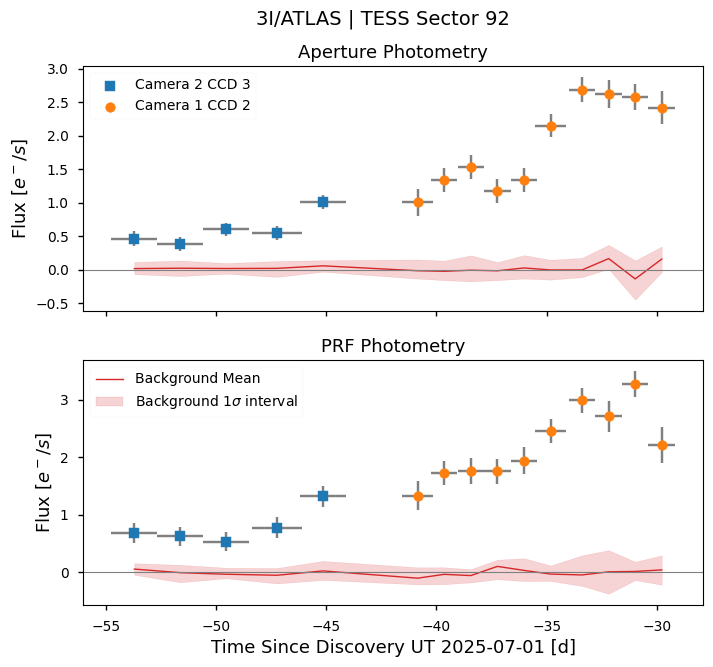

In [ ]:
with plt.style.context("seaborn-v0_8-notebook"):
    fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    fig.suptitle(f"{target} | TESS Sector {sector}", y=0.96, fontsize=14)

    ax[0].errorbar(
        lc.time_utc_geo - discovery_date.jd,
        lc.ap_flux,
        xerr=lc.time_win / 2,
        yerr=lc.ap_flux_err,
        fmt=".",
        c="gray",
    )
    # ax[0].fill_between(
    #     lc.time_utc_geo - discovery_date.jd, 
    #     lc.ap_flux_lo5, 
    #     lc.ap_flux_hi5, 
    #     color="gray", 
    #     alpha=0.2, 
    #     # label="Background $1\sigma$ interval"
    # )
    ax[1].errorbar(
        lc.time_utc_geo - discovery_date.jd,
        lc.prf_flux,
        xerr=lc.time_win / 2,
        yerr=lc.prf_flux_err,
        fmt=".",
        c="gray",
    )
    ax[0].plot(
        lc.time_utc_geo - discovery_date.jd, 
        lc.bkg_ap_flux, 
        c="tab:red", marker=None, 
        alpha=1, lw=1, 
        # label="Background Mean"
    )
    ax[0].fill_between(
        lc.time_utc_geo - discovery_date.jd, 
        lc.bkg_ap_flux_m, 
        lc.bkg_ap_flux_p, 
        color="tab:red", 
        alpha=0.2, 
        # label="Background $1\sigma$ interval"
    )
    ax[1].plot(
        lc.time_utc_geo - discovery_date.jd, 
        lc.bkg_prf_flux, 
        c="tab:red", marker=None, 
        alpha=1, lw=1, 
        label="Background Mean"
    )
    ax[1].fill_between(
        lc.time_utc_geo - discovery_date.jd, 
        lc.bkg_prf_flux_m, 
        lc.bkg_prf_flux_p, 
        color="tab:red", 
        alpha=0.2,
        label="Background $1\sigma$ interval"
    )

    c2 = lc.query("camera == 2")
    ax[0].scatter(
        c2.time_utc_geo - discovery_date.jd,
        c2.ap_flux,
        zorder=1000,
        marker="s",
        label=f"Camera {c2.camera.iloc[0]} CCD {c2.ccd.iloc[0]}",
    )
    ax[1].scatter(
        c2.time_utc_geo - discovery_date.jd, c2.prf_flux, zorder=1000, marker="s"
    )

    c1 = lc.query("camera == 1")

    ax[0].scatter(
        c1.time_utc_geo - discovery_date.jd,
        c1.ap_flux,
        zorder=1000,
        marker="o",
        label=f"Camera {c1.camera.iloc[0]} CCD {c1.ccd.iloc[0]}",
    )
    ax[1].scatter(
        c1.time_utc_geo - discovery_date.jd, c1.prf_flux, zorder=1000, marker="o"
    )
    ax[0].set_title("Aperture Photometry", fontsize=13)
    ax[1].set_title("PRF Photometry", fontsize=13)

    ax[0].set_ylabel("Flux [$e^-/s$]", fontsize=13)
    ax[1].set_ylabel("Flux [$e^-/s$]", fontsize=13)
    ax[1].set_xlabel(
        f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=13
    )

    ax[0].legend(fontsize="medium", framealpha=0.2)

    for axx in ax:
        # axx.axvline(
        #     (mpc1st - discovery_date).jd,
        #     c="gray",
        #     ls="--",
        #     lw=1.5,
        #     label=f"MPC First Observation ({mpc1st.iso[:10]})",
        # )
        axx.axhline(
            0,
            lw=0.8,
            c="gray",
        )
    ax[1].legend(fontsize="medium", framealpha=0.2)

    plt.savefig(
        f"../data/2025/figures/c2025n1_lc_flux_s{sector:04}.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()


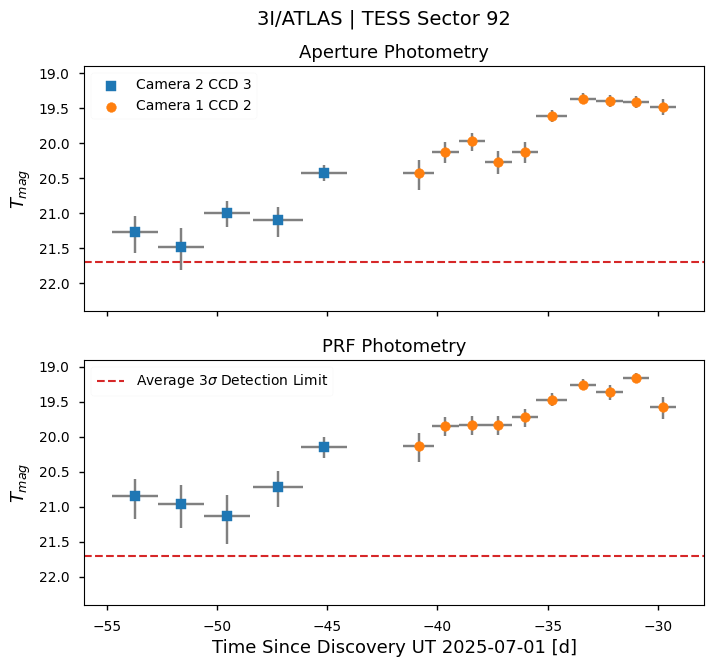

In [ ]:
with plt.style.context("seaborn-v0_8-notebook"):
    fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    fig.suptitle(f"{target} | TESS Sector {sector}", y=0.96, fontsize=14)

    ax[0].errorbar(
        lc.time_utc_geo - discovery_date.jd,
        lc.ap_mag,
        xerr=lc.time_win / 2,
        yerr=(lc.ap_mag_p, lc.ap_mag_m),
        fmt=".",
        c="gray",
    )
    # ax[0].plot(
    #     lc.time_utc_geo - discovery_date.jd,
    #     lc.ap_lim_mag,
    #     ls="-",
    #     c="tab:red",
    # )
    ax[1].errorbar(
        lc.time_utc_geo - discovery_date.jd,
        lc.prf_mag,
        xerr=lc.time_win / 2,
        yerr=(lc.prf_mag_p, lc.prf_mag_m),
        fmt=".",
        c="gray",
    )
    # ax[1].plot(
    #     lc.time_utc_geo - discovery_date.jd,
    #     lc.prf_lim_mag,
    #     ls="-",
    #     c="tab:red",
    # )
    c2 = lc.query("camera == 2")
    ax[0].scatter(
        c2.time_utc_geo - discovery_date.jd,
        c2.ap_mag,
        zorder=1000,
        marker="s",
        label=f"Camera {c2.camera.iloc[0]} CCD {c2.ccd.iloc[0]}",
    )
    ax[1].scatter(
        c2.time_utc_geo - discovery_date.jd, c2.prf_mag, zorder=1000, marker="s"
    )

    c1 = lc.query("camera == 1")

    ax[0].scatter(
        c1.time_utc_geo - discovery_date.jd,
        c1.ap_mag,
        zorder=1000,
        marker="o",
        label=f"Camera {c1.camera.iloc[0]} CCD {c1.ccd.iloc[0]}",
    )
    ax[1].scatter(
        c1.time_utc_geo - discovery_date.jd, c1.prf_mag, zorder=1000, marker="o"
    )

    ax[0].set_ylim((22.4, 18.9))
    ax[1].set_ylim((22.4, 18.9))
    ax[0].set_title("Aperture Photometry", fontsize=13)
    ax[1].set_title("PRF Photometry", fontsize=13)
    ax[0].legend(fontsize="medium", framealpha=0.2)

    for axx in ax:
        # axx.axvline(
        #     (mpc1st - discovery_date).jd,
        #     c="gray",
        #     ls="--", lw=1.5,
        #     label=f"MPC First Observation ({mpc1st.iso[:10]})",
        # )
        axx.axhline(
            np.mean(lc.ap_lim_mag.values), 
            c="tab:red", 
            ls="--", lw=1.5, 
            label="Average $3\sigma$ Detection Limit"
        )

    ax[0].set_ylabel("$T_{mag}$", fontsize=13)
    ax[1].set_ylabel("$T_{mag}$", fontsize=13)
    ax[1].set_xlabel(
        f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=13
    )
    ax[1].legend(fontsize="medium", framealpha=0.2)

    plt.savefig(
        f"../data/2025/figures/c2025n1_lc_mag_s{sector:04}.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()


## LATEX table

In [78]:
lc["time_iso"] = Time(lc.time_utc_geo, format="jd", scale="utc").iso
lc["snr_ap"] = np.abs(lc.ap_flux / np.mean(0.9*lc.bkg_ap_flux_std))
lc["snr_prf"] = np.abs(lc.prf_flux / np.mean(0.9*lc.bkg_prf_flux_std))

In [79]:
coord_org = SkyCoord(lc.ra_ephem.values, lc.dec_ephem.values, unit="deg")
lc["ra_ephem_hhmmss"] = coord_org.ra.to_string(unit=u.hourangle, format="latex", precision=0)
lc["dec_ephem_ddmmss"] = coord_org.dec.to_string(unit=u.deg, format="latex", precision=0)

coord_corr = SkyCoord(lc.ra_model.values, lc.dec_model.values, unit="deg")
lc["ra_model_hhmmss"] = coord_corr.ra.to_string(unit=u.hourangle, format="latex", precision=0)
lc["dec_model_ddmmss"] = coord_corr.dec.to_string(unit=u.deg, format="latex", precision=0)

lc["ra_offset"] = ((coord_org.ra - coord_corr.ra).to("arcsec")).value
lc["dec_offset"] = ((coord_org.dec - coord_corr.dec).to("arcsec")).value

lc["ra_offset_arcsec"] = ((coord_org.ra - coord_corr.ra).to("arcsec")).to_string(unit=u.arcsec, format="latex", precision=1)
lc["dec_offset_arcsec"] = ((coord_org.dec - coord_corr.dec).to("arcsec")).to_string(unit=u.arcsec, format="latex", precision=1)

lc["tmag_expected"] = lc["v_mag"] - 0.8
lc["time_stack"] = lc["nframes"] * cadence / 60 / 24

In [80]:
lc["tmag_expected"]

0     18.796467
1     18.734868
2     18.673426
3     18.604286
4     18.541742
5     18.409173
6     18.371682
7     18.333663
8     18.295503
9     18.258012
10    18.219312
11    18.173593
12    18.136076
13    18.097626
14    18.057976
Name: tmag_expected, dtype: float64

In [441]:
lc.loc[:, list(cols_latex.keys())]

,time_iso,time_stack,ra_model_hhmmss,dec_model_ddmmss,ap_flux,ap_flux_err,ap_mag,ap_mag_m,ap_mag_p,prf_flux,...,prf_mag,prf_mag_m,prf_mag_p,snr_ap,snr_prf,ra_ephem_hhmmss,dec_ephem_ddmmss,ra_offset_arcsec,dec_offset_arcsec,tmag_expected
0,2025-05-08 12:25:25.712,2.085648,$19^{\mathrm{h}}12^{\mathrm{m}}35^{\mathrm{s}}$,$-18^\circ42{}^\prime22{}^{\prime\prime}$,0.463416,0.111415,21.275073,0.298569,0.233924,0.686267,...,20.848767,0.324213,0.249333,3.184961,3.582465,$19^{\mathrm{h}}12^{\mathrm{m}}35^{\mathrm{s}}$,$-18^\circ42{}^\prime18{}^{\prime\prime}$,$-10.2\mathrm{{}^{\prime\prime}}$,$4.0\mathrm{{}^{\prime\prime}}$,18.796467
1,2025-05-10 14:29:03.709,2.085648,$19^{\mathrm{h}}11^{\mathrm{m}}27^{\mathrm{s}}$,$-18^\circ41{}^\prime22{}^{\prime\prime}$,0.383162,0.103375,21.481545,0.341386,0.259333,0.621624,...,20.956181,0.351553,0.265137,2.633391,3.245014,$19^{\mathrm{h}}11^{\mathrm{m}}26^{\mathrm{s}}$,$-18^\circ41{}^\prime29{}^{\prime\prime}$,$-12.3\mathrm{{}^{\prime\prime}}$,$-7.2\mathrm{{}^{\prime\prime}}$,18.734868
2,2025-05-12 16:32:40.821,2.085648,$19^{\mathrm{h}}10^{\mathrm{m}}12^{\mathrm{s}}$,$-18^\circ40{}^\prime49{}^{\prime\prime}$,0.598127,0.099762,20.998016,0.198115,0.167483,0.531216,...,21.126822,0.402905,0.293193,4.110805,2.773066,$19^{\mathrm{h}}10^{\mathrm{m}}11^{\mathrm{s}}$,$-18^\circ40{}^\prime55{}^{\prime\prime}$,$-13.1\mathrm{{}^{\prime\prime}}$,$-6.1\mathrm{{}^{\prime\prime}}$,18.673426
3,2025-05-14 23:46:18.748,2.085648,$19^{\mathrm{h}}08^{\mathrm{m}}43^{\mathrm{s}}$,$-18^\circ40{}^\prime42{}^{\prime\prime}$,0.541200,0.104322,21.106606,0.232495,0.191384,0.776069,...,20.715250,0.286845,0.226682,3.719555,4.051249,$19^{\mathrm{h}}08^{\mathrm{m}}42^{\mathrm{s}}$,$-18^\circ40{}^\prime44{}^{\prime\prime}$,$-11.7\mathrm{{}^{\prime\prime}}$,$-1.7\mathrm{{}^{\prime\prime}}$,18.604286
4,2025-05-17 01:49:54.213,2.085648,$19^{\mathrm{h}}07^{\mathrm{m}}17^{\mathrm{s}}$,$-18^\circ40{}^\prime52{}^{\prime\prime}$,1.012324,0.107415,20.426701,0.121786,0.109493,1.319809,...,20.138722,0.165459,0.143546,6.957498,6.889695,$19^{\mathrm{h}}07^{\mathrm{m}}16^{\mathrm{s}}$,$-18^\circ40{}^\prime58{}^{\prime\prime}$,$-9.6\mathrm{{}^{\prime\prime}}$,$-6.6\mathrm{{}^{\prime\prime}}$,18.541742
5,2025-05-21 08:47:03.690,1.206019,$19^{\mathrm{h}}04^{\mathrm{m}}11^{\mathrm{s}}$,$-18^\circ42{}^\prime05{}^{\prime\prime}$,1.002730,0.197593,20.437041,0.238286,0.195286,1.329092,...,20.131112,0.230730,0.190188,6.891555,6.938154,$19^{\mathrm{h}}04^{\mathrm{m}}11^{\mathrm{s}}$,$-18^\circ42{}^\prime18{}^{\prime\prime}$,$-6.2\mathrm{{}^{\prime\prime}}$,$-12.9\mathrm{{}^{\prime\prime}}$,18.409173
6,2025-05-22 13:43:52.925,1.206019,$19^{\mathrm{h}}03^{\mathrm{m}}13^{\mathrm{s}}$,$-18^\circ41{}^\prime54{}^{\prime\prime}$,1.332778,0.177718,20.128106,0.155383,0.135904,1.724378,...,19.848419,0.143459,0.126697,9.159909,9.001634,$19^{\mathrm{h}}03^{\mathrm{m}}13^{\mathrm{s}}$,$-18^\circ42{}^\prime06{}^{\prime\prime}$,$-2.9\mathrm{{}^{\prime\prime}}$,$-12.4\mathrm{{}^{\prime\prime}}$,18.371682
7,2025-05-23 18:40:41.875,1.206019,$19^{\mathrm{h}}02^{\mathrm{m}}11^{\mathrm{s}}$,$-18^\circ41{}^\prime38{}^{\prime\prime}$,1.528696,0.177062,19.979198,0.133655,0.118991,1.752653,...,19.830760,0.148633,0.130714,10.506412,9.149237,$19^{\mathrm{h}}02^{\mathrm{m}}11^{\mathrm{s}}$,$-18^\circ41{}^\prime50{}^{\prime\prime}$,$-1.6\mathrm{{}^{\prime\prime}}$,$-11.2\mathrm{{}^{\prime\prime}}$,18.333663
8,2025-05-24 23:37:30.440,1.206019,$19^{\mathrm{h}}01^{\mathrm{m}}07^{\mathrm{s}}$,$-18^\circ41{}^\prime28{}^{\prime\prime}$,1.170503,0.177062,20.269069,0.178077,0.152943,1.752958,...,19.830571,0.143709,0.126892,8.044625,9.150826,$19^{\mathrm{h}}01^{\mathrm{m}}07^{\mathrm{s}}$,$-18^\circ41{}^\prime37{}^{\prime\prime}$,$-2.0\mathrm{{}^{\prime\prime}}$,$-9.6\mathrm{{}^{\prime\prime}}$,18.295503
9,2025-05-26 04:34:18.630,1.206019,$19^{\mathrm{h}}00^{\mathrm{m}}00^{\mathrm{s}}$,$-18^\circ41{}^\prime24{}^{\prime\prime}$,1.332946,0.182171,20.127969,0.159555,0.139084,1.940044,...,19.72047

In [442]:
cols_latex = {
    "time_iso": lambda x: f"{x:s}", 
    "time_stack": lambda x: f"{x:.1f}", 
    "ra_model_hhmmss": lambda x: f"{x:s}", 
    "dec_model_ddmmss": lambda x: f"{x:s}", 
    "ap_flux": lambda x: f"{x:.3f}", 
    "ap_flux_err": lambda x: f"{x:.3f}", 
    "ap_mag": lambda x: f"{x:.2f}", 
    "ap_mag_m": lambda x: f"{x:.2f}", 
    "ap_mag_p": lambda x: f"{x:.2f}", 
    "prf_flux": lambda x: f"{x:.3f}", 
    "prf_flux_err": lambda x: f"{x:.3f}", 
    "prf_mag": lambda x: f"{x:.2f}", 
    "prf_mag_m": lambda x: f"{x:.2f}", 
    "prf_mag_p": lambda x: f"{x:.2f}", 
    "snr_ap": lambda x: f"{x:.1f}", 
    "snr_prf": lambda x: f"{x:.1f}", 
    "ra_ephem_hhmmss": lambda x: f"{x:s}", 
    "dec_ephem_ddmmss": lambda x: f"{x:s}", 
    "ra_offset_arcsec": lambda x: f"{x:s}", 
    "dec_offset_arcsec": lambda x: f"{x:s}", 
    "tmag_expected": lambda x: f"{x:.2f}", 
}

print(
    lc.loc[:, list(cols_latex.keys())].to_latex(index=False, formatters=cols_latex)
)

\begin{tabular}{lrllrrrrrrrrrrrrllllr}
\toprule
time_iso & time_stack & ra_model_hhmmss & dec_model_ddmmss & ap_flux & ap_flux_err & ap_mag & ap_mag_m & ap_mag_p & prf_flux & prf_flux_err & prf_mag & prf_mag_m & prf_mag_p & snr_ap & snr_prf & ra_ephem_hhmmss & dec_ephem_ddmmss & ra_offset_arcsec & dec_offset_arcsec & tmag_expected \\
\midrule
2025-05-08 12:25:25.712 & 2.1 & $19^{\mathrm{h}}12^{\mathrm{m}}35^{\mathrm{s}}$ & $-18^\circ42{}^\prime22{}^{\prime\prime}$ & 0.463 & 0.111 & 21.28 & 0.30 & 0.23 & 0.686 & 0.177 & 20.85 & 0.32 & 0.25 & 3.2 & 3.6 & $19^{\mathrm{h}}12^{\mathrm{m}}35^{\mathrm{s}}$ & $-18^\circ42{}^\prime18{}^{\prime\prime}$ & $-10.2\mathrm{{}^{\prime\prime}}$ & $4.0\mathrm{{}^{\prime\prime}}$ & 18.80 \\
2025-05-10 14:29:03.709 & 2.1 & $19^{\mathrm{h}}11^{\mathrm{m}}27^{\mathrm{s}}$ & $-18^\circ41{}^\prime22{}^{\prime\prime}$ & 0.383 & 0.103 & 21.48 & 0.34 & 0.26 & 0.622 & 0.172 & 20.96 & 0.35 & 0.27 & 2.6 & 3.2 & $19^{\mathrm{h}}11^{\mathrm{m}}26^{\mathrm{s}}$ & $-18

# MPC data

In [81]:
import requests
from tess_ephem.ephem import _get_horizons_ephem

In [82]:
s92 = np.array([2460802.9695323096, 2460829.644819287])

In [83]:
response = requests.get("https://data.minorplanetcenter.net/api/get-obs", json={"desigs": ["3I"], "output_format":["ADES_DF"]})

if response.ok:
    mpc = pd.DataFrame(response.json()[0]['ADES_DF'])
else:
    print("Error: ", response.status_code, response.content)
mpc["time_jd"] = Time(mpc.obstime.values.astype(str), format="isot", scale="utc").jd
mpc

,Obstype,artsat,astcat,band,com,ctr,dec,decstar,delay,deltadec,...,seeing,stn,subfmt,subfrm,sys,trkid,trksub,trx,unctime,time_jd
0,optical,None,Gaia2,V,None,399.0,-18.705931,None,None,None,...,None,C57,A17,None,ICRF_KM,00000Iy0sY,aa,None,None,2.460804e+06
1,optical,None,Gaia2,V,None,399.0,-18.689362,None,None,None,...,None,C57,A17,None,ICRF_KM,00000Iy0sZ,aa,None,None,2.460806e+06
2,optical,None,Gaia2,V,None,399.0,-18.680432,None,None,None,...,None,C57,A17,None,ICRF_KM,00000Iy0sa,aa,None,None,2.460808e+06
3,optical,None,Gaia2,V,None,399.0,-18.678503,None,None,None,...,None,C57,A17,None,ICRF_KM,00000Iy0sb,aa,None,None,2.460810e+06
4,optical,None,Gaia1,r,None,NaN,-18.694300,None,None,None,...,None,I41,A17,None,None,00000IyQ4h,None,None,None,2.460811e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4215,optical,None,ATLAS2,Vj,None,NaN,-10.285544,None,None,None,...,None,Y05,A17,None,None,00000J5JhV,S001049,None,0.023,2.460954e+06
4216,optical,None,ATLAS2,Vj,None,NaN,-10.285421,None,None,None,...,None,Y05,A17,None,None,00000J5JhV,S001049,None,0.023,2.460954e+06
4217,optical,None,Gaia3,G,None,NaN,-10.274685,None,None,None,...,5.6,W57,A17,None,None,00000J742e,None,None,None,2.460954e+06
4218,optical,None,Gaia3,G,None,NaN,-10.274332,None,None,None,...,6.0,W57,A17,None,None,00000J742e,None,None,None,2.460954e+06


In [ ]:
lsst = pd.read_csv("../data/2025/3i_lsst.csv", index_col=0)
lsst["time_jd"] = Time(lsst.DateMidpoint.values.astype(str), format="isot", scale="utc").jd
lsst["stn"] = "X05"
lsst.head()

,DateMidpoint,Filter,Meas_RA,MeasDec,Mag,MagErr,r,Delta,Elong,Phase,SkyVel,SkyPA,time_jd,stn
Row,,,,,,,,,,,,,,
1,2025-06-21T08:11:32.665,z,NaN,NaN,NaN,NaN,4.839,3.830,172.22,1.63,1.021,270.25,2.460848e+06,X05
2,2025-06-22T02:32:47.429,g,NaN,NaN,NaN,NaN,4.813,3.803,173.02,1.47,1.037,270.11,2.460849e+06,X05
3,2025-06-22T03:07:49.625,r,NaN,NaN,NaN,NaN,4.813,3.802,173.05,1.46,1.038,270.13,2.460849e+06,X05
4,2025-06-24T03:07:46.213,i,NaN,NaN,NaN,NaN,4.746,3.733,174.77,1.12,1.079,270.33,2.460851e+06,X05
5,2025-06-30T02:25:46.504,i,NaN,NaN,NaN,NaN,4.546,3.536,172.45,1.68,1.199,270.96,2.460857e+06,X05


In [85]:
def read_ztf_data(url):
    # Fetch the content from the URL
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad status codes
    
    lines = response.text.splitlines()
    
    # Find the start and end of the byte-by-byte description
    start_index = -1
    end_index = -1
    for i, line in enumerate(lines):
        if "Byte-by-byte Description" in line:
            start_index = i + 3
        if start_index != -1 and "---" in line and i > start_index:
            end_index = i
            break

    # Parse the header to get column widths and names
    col_specs = []
    col_names = []
    if start_index != -1 and end_index != -1:
        for i in range(start_index, end_index):
            parts = lines[i].split()
            byte_range = parts[0].split('-')
            print(byte_range)
            start_col = int(byte_range[0]) - 1
            end_col = int(byte_range[1])
            col_specs.append((start_col, end_col))
            col_names.append(parts[3])

    # Read the data using read_fwf
    # The data starts at line 21 (index 20)
    data_string = "\\n".join(lines[20:])
    df = pd.read_fwf(io.StringIO(data_string), colspecs=col_specs, header=None)
    df.columns = col_names
    
    return df

In [89]:
ztf = pd.read_fwf("https://gist.githubusercontent.com/Yeqzids/0dc0b22f725c623355ada85588a15b72/raw/b7d04d3fa06806a9758d97d6f28d725edd83f54c/ztf_3i_table.txt", skiprows=20, 
            names=["jd_mid", "jd_start", "jd_end", "band", "mag_ap_cor", "magerr_ap", "mag_3sig", "Nnight", "rh", "delta", "phase"])

ztf["time_utc"] = ztf["jd_mid"]
ztf["mag"] = ztf["mag_ap_cor"]
ztf["mag_e"] = ztf["magerr_ap"]
ztf["stn"] = "I41"
ztf.head()

,jd_mid,jd_start,jd_end,band,mag_ap_cor,magerr_ap,mag_3sig,Nnight,rh,delta,phase,time_utc,mag,mag_e,stn
0,2.460502e+06,2.460477e+06,2.460523e+06,r,NaN,NaN,21.675021,24.0,16.566000,15.579000,0.75000,2.460502e+06,NaN,NaN,I41
1,2.460544e+06,2.460526e+06,2.460563e+06,r,NaN,NaN,22.015121,27.0,15.139000,14.406000,2.59000,2.460544e+06,NaN,NaN,I41
2,2.460544e+06,2.460526e+06,2.460563e+06,r,NaN,NaN,22.015121,27.0,15.139000,14.406000,2.59000,2.460544e+06,NaN,NaN,I41
3,2.460797e+06,2.460788e+06,2.460805e+06,r,21.617140,0.247000,NaN,5.0,6.540000,6.075000,8.08000,2.460797e+06,21.617140,0.247000,I41
4,2.460811e+06,NaN,NaN,r,20.166126,0.126617,NaN,NaN,6.081056,5.404335,7.51125,2.460811e+06,20.166126,0.126617,I41


In [90]:
# atlas pre-discovery

atlas = pd.read_csv("http://astroportal.ifa.hawaii.edu/atlas/3I-photometry/3Iphot_table.txt", skiprows=31, 
                    names=["StackID","MJD","Filt","N", "m2", "m6", "m10", "m14", "dm6", "r", "delta", "sto", "Phi"], delim_whitespace=True
                   )
atlas["time_utc"] = atlas["MJD"] + 2400000.5
atlas["band"] = "A"+atlas["Filt"].values
atlas["mag"] = atlas["m6"]
atlas["mag_e"] = atlas["dm6"]
atlas["stn"] = "T05"

atlas

/var/folders/9v/pf39l8vn4dv810cyn39k_xk05nh7q7/T/ipykernel_41814/3960944942.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  atlas = pd.read_csv("http://astroportal.ifa.hawaii.edu/atlas/3I-photometry/3Iphot_table.txt", skiprows=31,


,StackID,MJD,Filt,N,m2,m6,m10,m14,dm6,r,delta,sto,Phi,time_utc,band,mag,mag_e,stn
0,60760-60764o,60762.4563,o,12,24.14,23.74,21.71,21.06,1.88,7.705,7.840,7.29,0.55,2.460763e+06,Ao,23.74,1.88,T05
1,60762-60766c,60764.7003,c,12,23.39,22.49,22.78,22.78,0.57,7.628,7.725,7.42,0.55,2.460765e+06,Ac,22.49,0.57,T05
2,60791-60792c,60791.5831,c,8,23.27,22.16,21.76,21.94,0.43,6.718,6.340,8.20,0.59,2.460792e+06,Ac,22.16,0.43,T05
3,60786-60798o,60792.5380,o,29,23.70,21.61,21.96,21.86,0.19,6.685,6.292,8.17,0.59,2.460793e+06,Ao,21.61,0.19,T05
4,60818-60826c,60821.2754,o,17,22.73,20.63,20.14,19.90,0.07,5.714,4.897,6.43,0.51,2.460822e+06,Ao,20.63,0.07,T05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,03a60905,60904.8024,o,4,18.84,16.80,16.26,16.03,0.01,2.953,2.642,19.86,1.00,2.460905e+06,Ao,16.80,0.01,T05
71,05r60908,60907.8897,w,4,18.96,16.97,16.47,16.28,0.01,2.856,2.623,20.73,1.02,2.460908e+06,Aw,16.97,0.01,T05
72,04a60914,60914.0567,o,4,18.44,16.40,15.88,15.65,0.01,2.666,2.593,22.11,1.07,2.460915e+06,Ao,16.40,0.01,T05
73,02a60916,60916.2574,o,4,18.36,16.34,15.83,15.59,0.01,2.599,2.585,22.48,1.08,2.460917e+06,Ao,16.34,0.01,T05


In [91]:
# Combine MPC and Rubin observations
cols = ["time_utc", "band", "mag", "mag_e", "stn"]
others_lc = pd.concat([
    mpc.rename(columns={"time_jd": "time_utc", "band": "band", "mag": "mag", "rmsmag": "mag_e"}).loc[:, cols],
    lsst.rename(columns={"time_jd": "time_utc", "Filter": "band", "Mag": "mag", "MagErr": "mag_e"}).loc[:, cols],
    atlas.loc[:, cols],
    ztf.loc[:, cols],
], axis=0
).sort_values("time_utc").reset_index(drop=True)
others_lc["time_utc"] = others_lc["time_utc"].astype(float)
others_lc["mag"] = others_lc["mag"].astype(float)
others_lc["mag_e"] = others_lc["mag_e"].astype(float)
others_lc

,time_utc,band,mag,mag_e,stn
0,2.460502e+06,r,NaN,NaN,I41
1,2.460544e+06,r,NaN,NaN,I41
2,2.460544e+06,r,NaN,NaN,I41
3,2.460763e+06,Ao,23.74,1.88,T05
4,2.460765e+06,Ac,22.49,0.57,T05
...,...,...,...,...,...
4382,2.460954e+06,Vj,13.20,0.62,Y05
4383,2.460954e+06,Vj,12.70,0.77,Y05
4384,2.460954e+06,G,13.40,0.30,W57
4385,2.460954e+06,G,13.40,0.30,W57


In [92]:
others_lc.band.unique()

array(['r', 'Ao', 'Ac', 'V', 'c', 'g', None, 'Aw', 'z', 'i', 'G', 'Vj',
       'w', 'R', 'Sr', 'Rc', 'Gr', 'UNK', 'y', 'Sz', 'Sg', 'Si'],
      dtype=object)

In [93]:
feinstein = np.array([
    [(3802.975926 + 3813.474497)/2, np.abs(3802.975926 - 3813.474497)/2, 20.83, 0.05],
    [(3815.799580 + 3828.911416)/2, np.abs(3815.799580 - 3828.911416)/2, 19.28, 0.05],
])
feinstein[:, 0] += btjd0 

In [94]:
tstart = Time(others_lc.time_utc.values[0], scale="utc", format="jd")
tstop  = Time(others_lc.time_utc.values[-1], scale="utc", format="jd")

# geo obs
ephems = _get_horizons_ephem("C/2025 N1", start=tstart, stop=tstop, step="6H", location='399').to_pandas()
ephems

,targetname,datetime_str,datetime_jd,M1,solar_presence,k1,lunar_presence,RA,DEC,RA_rate,...,Tmag,Nmag,r,r_rate,delta,delta_rate,TDB-UT,alpha_true,PABLon,PABLat
0,ATLAS (C/2025 N1),2024-Jul-10 06:23:05.856,2.460502e+06,12.3,*,4.5,m,289.21311,-19.32067,-11.0046,...,23.744,<NA>,16.562536,-58.627437,15.547147,-58.826560,69.183873,0.1789,288.1186,2.8290
1,ATLAS (C/2025 N1),2024-Jul-10 12:23:05.856,2.460502e+06,12.3,,4.5,m,289.19351,-19.32285,-11.1653,...,23.742,<NA>,16.554070,-58.627629,15.538661,-58.576760,69.183867,0.1800,288.1078,2.8292
2,ATLAS (C/2025 N1),2024-Jul-10 18:23:05.856,2.460502e+06,12.3,C,4.5,,289.17377,-19.32498,-11.1373,...,23.740,<NA>,16.545603,-58.627820,15.530245,-58.001627,69.183862,0.1826,288.0971,2.8295
3,ATLAS (C/2025 N1),2024-Jul-11 00:23:05.856,2.460503e+06,12.3,*,4.5,m,289.15422,-19.32706,-10.9997,...,23.738,<NA>,16.537136,-58.628012,15.521879,-57.985493,69.183854,0.1864,288.0864,2.8297
4,ATLAS (C/2025 N1),2024-Jul-11 06:23:05.856,2.460503e+06,12.3,*,4.5,m,289.13478,-19.32922,-11.0516,...,23.736,<NA>,16.528669,-58.628204,15.513481,-58.289523,69.183846,0.1914,288.0757,2.8300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1818,ATLAS (C/2025 N1),2025-Oct-07 18:23:05.856,2.460956e+06,12.3,,4.5,m,213.12627,-10.04930,-70.0395,...,15.148,<NA>,1.571307,-31.796157,2.471108,-8.739617,69.182374,12.6777,220.6132,4.0037
1819,ATLAS (C/2025 N1),2025-Oct-08 00:23:05.856,2.460957e+06,12.3,*,4.5,,213.00695,-10.01744,-71.0102,...,15.141,<NA>,1.566735,-31.526930,2.469829,-8.843208,69.182374,12.4902,220.3962,3.9970
1820,ATLAS (C/2025 N1),2025-Oct-08 06:23:05.856,2.460957e+06,12.3,*,4.5,,212.88657,-9.98536,-71.0277,...,15.134,<NA>,1.562203,-31.255192,2.468579,-8.461026,69.182372,12.3020,220.1779,3.9903
1821,ATLAS (C/2025 N1),2025-Oct-08 12:23:05.856,2.460957e+06,12.3,,4.5,m,212.76723,-9.95303,-70.0593,...,15.127,<NA>,1.557709,-30.980935,2.467361,-8.550733,69.182373,12.1112,219.9590,3.9837


In [95]:
times_all = np.linspace(tstart.jd, tstop.jd, 200)
d_helio = np.interp(times_all, ephems.datetime_jd, ephems.r)
dummy_y = np.ones_like(d_helio) * 17

In [96]:
plot_filters = [["r","i","z"],
                ["Sr","Si","Sz"], 
                ["R"], 
                ["Rc"],
                # ["G","R"], 
                ["Ao"], 
                # ["S"], 
                # ["c"]
               ]
plot_colors = [plt.get_cmap("Paired")(np.linspace(0, 1, 6))[:3],
               plt.get_cmap("Paired")(np.linspace(0, 1, 6))[:3],
               ["crimson"],
               ["crimson"],
               # ["tab:green","crimson"],
               ["tab:orange"],
               # ["gray"], 
               # ["blue"]
              ]
plot_teslecope = ["X05", "W68", "T05", "W84"]

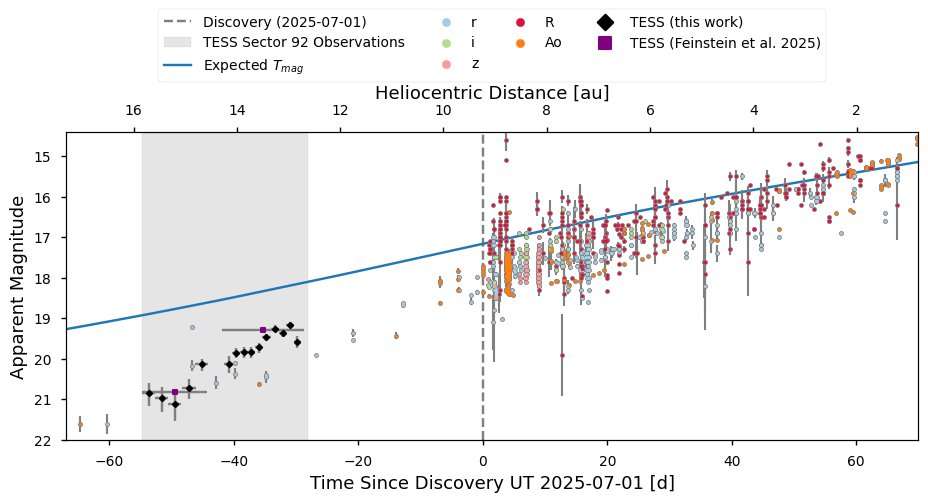

In [ ]:
with plt.style.context('seaborn-v0_8-notebook'):
    fig, ax = plt.subplots(figsize=(11,4))
    to_plot = []

    # ax.axvline(mpc1st.jd-discovery_date.jd, c="gray", ls="--", label=f"MPC First Observation ({mpc1st.iso[:10]})")
    ax.axvline(0, c="gray", ls="--", label=f"Discovery ({discovery_date.iso[:10]})")
    
    ax.fill_betweenx(np.arange(10, 30), s92[0]- discovery_date.jd, s92[1]- discovery_date.jd, 
                      color='gray', alpha=0.2, label='TESS Sector 92 Observations'
                     )
    ax.plot(ephems.datetime_jd - discovery_date.jd, ephems.Tmag-0.8, c="tab:blue", label="Expected $T_{mag}$")
    
    colors = plt.get_cmap("tab20_r")(np.linspace(0, 1, len(others_lc.band.unique())))
    
    for i, bands in enumerate(plot_filters):
        for k, band in enumerate(bands):
            aux = others_lc.query(f"band == '{band}'")
            to_plot.append(aux.stn.values.tolist())
            label = None if "S" in band else (None if "c" in band else band)
            ax.scatter(aux.time_utc - discovery_date.jd, aux.mag, label=label, s=4, zorder=10000, color=plot_colors[i][k])
            ax.errorbar(aux.time_utc - discovery_date.jd, aux.mag, yerr=aux.mag_e, fmt=".", c="gray", lw=1.5)
    
    ax.errorbar(lc.time_utc_geo - discovery_date.jd, lc.prf_mag, xerr=lc.time_win/2, yerr=(lc.prf_mag_p, lc.prf_mag_m), fmt=".", c="gray")
    ax.scatter(lc.time_utc_geo - discovery_date.jd, lc.prf_mag, s=7, zorder=10000, c="k", marker="D", label="TESS (this work)", lw=1.5)

    ax.errorbar(feinstein[:, 0] - discovery_date.jd, feinstein[:, 2], xerr=feinstein[:, 1], yerr=feinstein[:, 3], fmt=".", c="gray")
    ax.scatter(feinstein[:, 0] - discovery_date.jd, feinstein[:, 2], s=7, zorder=10000, c="purple", marker="s", label="TESS (Feinstein et al. 2025)", lw=1.5)
    
    ax.legend(ncols=4, markerscale=3, fontsize="medium", loc="upper center", bbox_to_anchor=(0.5, 1.42), reverse=False)
    ax.set_ylabel("Apparent Magnitude", fontsize=13)
    ax.set_xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=13)
    ax.set_ylim(22., 14.4)
    # ax.gca().invert_yaxis()

    axt = ax.twiny()
    axt.scatter(d_helio, dummy_y, marker=".", s=0)
    axt.invert_xaxis()
    axt.set_xlabel(f"Heliocentric Distance [au]", fontsize=13)
    # axt.set_xlim(6., 3.2)
    ax.set_xlim(-67, 70)
    
    # plt.savefig(
    #     f"../data/2025/figures/c2025n1_mpclc_s{sector:04}.pdf",
    #     format="pdf", bbox_inches='tight',
    # )
    plt.show()

In [98]:
tel_codes, n_points = np.unique([item for sublist in to_plot for item in sublist], return_counts=True)
tel_codes

array(['056', '071', '106', '213', '215', '232', '247', '349', '367',
       '585', '829', '834', '874', '903', 'A05', 'A77', 'B72', 'B96',
       'C23', 'D88', 'D95', 'H36', 'H45', 'H78', 'I41', 'I47', 'I75',
       'J01', 'J13', 'J47', 'J51', 'J96', 'L90', 'M06', 'M18', 'M22',
       'M50', 'M57', 'O18', 'Q11', 'Q23', 'Q62', 'R49', 'R50', 'R95',
       'T05', 'U94', 'W68', 'W84', 'W96', 'X05', 'X07', 'X19', 'X74',
       'Y16', 'Y71', 'Z09'], dtype='<U3')

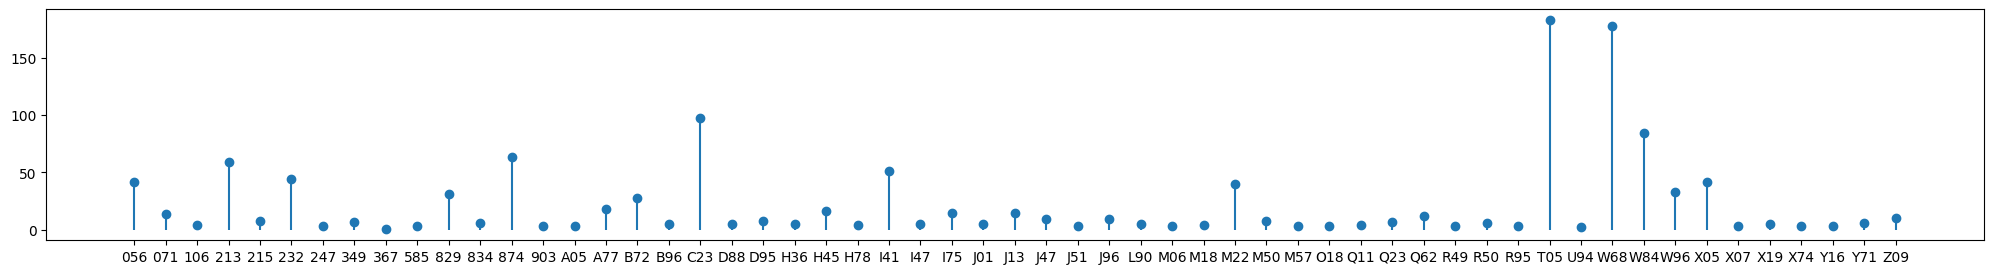

In [99]:
plt.figure(figsize=(25,3))
plt.errorbar(tel_codes, n_points, yerr=(n_points, n_points*0), fmt="o")
plt.show()

In [100]:
from astroquery.mpc import MPC

In [101]:
for code in tel_codes[np.argsort(n_points, )][::-1]:
    print(code, MPC.get_observatory_location(code)[3])

T05 ATLAS-HKO, Haleakala
W68 ATLAS Chile, Rio Hurtado
C23 Olmen
W84 Cerro Tololo-DECam
874 Observatorio do Pico dos Dias, Itajuba
213 Observatorio Montcabre
I41 Palomar Mountain--ZTF
232 Masquefa Observatory
056 Skalnate Pleso
X05 Simonyi Survey Telescope, Rubin Observatory
M22 ATLAS South Africa, Sutherland
W96 CAO, San Pedro de Atacama (since 2013)
829 Complejo Astronomico El Leoncito
B72 Soerth Observatory
A77 Observatoire Chante-Perdrix, Dauban
H45 Arkansas Sky Obs., Petit Jean Mountain South
I75 Observatorio Los Caracoles, Castello
J13 La Palma-Liverpool Telescope
071 NAO Rozhen, Smolyan
Q62 iTelescope Observatory, Siding Spring
Z09 Old Orchard Observatory, Fiddington
J96 Observatorio de Cantabria
J47 Observatorio Nazaret
M50 Virtual Telescope Project, Manciano
215 Buchloe
D95 Kurihara
349 Ageo
Q23 Sukagawa
834 Buenos Aires-AAAA
Y71 Makroskooppi, Fregenal de la Sierra
R50 Obsservatorio astronomico Orion
H36 Sandlot Observatory, Scranton
X19 Santel Observatory, El Leoncito
B96 Brix

# Plot stacked images

In [ ]:
data1 = np.load("../data/2025/3i_s0092_2-3_images_v3_ephemcorr.npz")
data2 = np.load("../data/2025/3i_s0092_1-2_images_v3_ephemcorr.npz")

In [104]:
img_stack = np.concatenate([data1["stacked_flux"], data2["stacked_flux"]])
err_stack = np.concatenate([data1["stacked_err"], data2["stacked_err"]])
prf_apers = np.concatenate([data1["prf_aperture"][None, :], data2["prf_aperture"][None, :]])

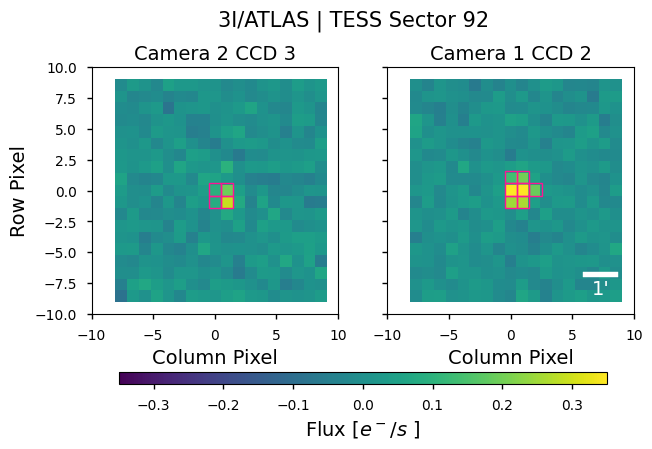

In [ ]:
with plt.style.context('seaborn-v0_8-notebook'):
    fig, ax = plt.subplots(1,2, figsize=(7,5), sharex=True, sharey=True)
    fig.suptitle(f"{target} | TESS Sector {sector}", y=0.95, fontsize=15)

    row_plot = np.arange(0, img_stack.shape[1]) - img_stack.shape[1]/2 + 0.5
    col_plot = np.arange(0, img_stack.shape[2]) - img_stack.shape[2]/2 + 0.5
    extent = (col_plot[0], col_plot[-1], row_plot[0], row_plot[-1])

    ax[0].imshow(data1["full_stack"], origin="lower", vmin=-0.3, vmax=0.3, extent=extent)

    bar = ax[1].imshow(data2["full_stack"], origin="lower", vmin=-0.35, vmax=0.35, extent=extent)
    cbar = plt.colorbar(bar, ax=ax, orientation="horizontal", shrink=.9, aspect=40
                       ).set_label(label="Flux [$e^-/s$ ]", size=14)
    ax[0].set_xlabel("Column Pixel", fontsize=14)
    ax[1].set_xlabel("Column Pixel", fontsize=14)
    ax[0].set_ylabel("Row Pixel", fontsize=14)

    ax[0].set_title("Camera 2 CCD 3", fontsize=14)
    ax[1].set_title("Camera 1 CCD 2", fontsize=14)

    for k in range(len(prf_apers)):
        for i, pi in enumerate(row_plot):
            for j, pj in enumerate(col_plot):
                if prf_apers[k, i, j]:
                    # print("here")
                    rect = patches.Rectangle(
                        xy=(pj - 0.5, pi - 0.4),
                        width=1,
                        height=1,
                        color="deeppink",
                        fill=False,
                        # hatch="//",
                        alpha=1,
                        lw=1,
                    )
                    ax[k].add_patch(rect)

    # scale bar
    fontprops = fm.FontProperties(size=14)
    scalebar = AnchoredSizeBar(ax[1].transData,
                               2.86, "1'", 'lower right', 
                               pad=1,
                               borderpad=-0.2,
                               color="w",
                               frameon=False,
                               size_vertical=0.4,
                               fill_bar=True,
                               fontproperties=fontprops)
    
    ax[1].add_artist(scalebar)

    # plt.savefig(
    #     f"../data/2025/figures/c2025n1_full_stack_all_s{sector:04}.pdf",
    #     format="pdf", bbox_inches='tight',
    # )

    plt.show()

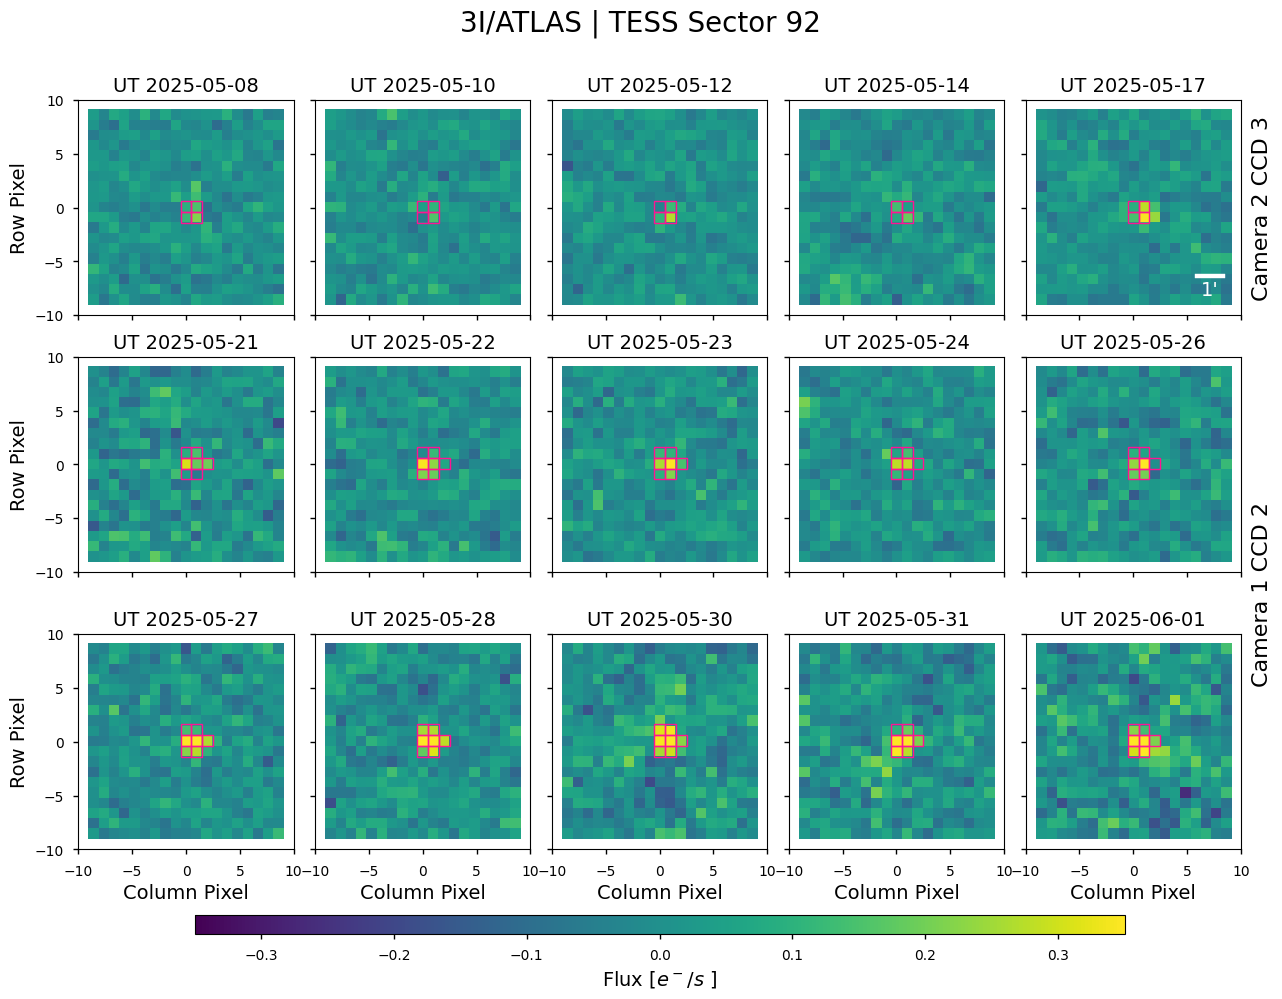

In [ ]:
with plt.style.context('seaborn-v0_8-notebook'):
    ncols = 5
    
    fig, ax = plt.subplots(3, ncols, figsize=(15, 10), sharex=True, sharey=True, squeeze=False)
    fig.suptitle(f"{target} | TESS Sector {sector}", y=0.95, fontsize=20)
    
    row_plot = np.arange(0, img_stack.shape[1]) - img_stack.shape[1]/2 + 0.5
    col_plot = np.arange(0, img_stack.shape[2]) - img_stack.shape[2]/2 + 0.5
    
    extent = (col_plot[0], col_plot[-1], row_plot[0], row_plot[-1])
    
    for fno, img in enumerate(img_stack):
    
        # plotting stuff
        ax.ravel()[fno].set_title(
            f'UT {lc["time_iso"].iloc[fno][:10]}', 
            fontsize=14
        )
        # plot image
        if fno > 4:
            vmin = -0.4
            vmax = 0.4
            ax.ravel()[fno].imshow(img, origin="lower", vmin=vmin, vmax=vmax, extent=extent)
        else:
            vmin = -0.35
            vmax = 0.35
            bar = ax.ravel()[fno].imshow(img, origin="lower", vmin=vmin, vmax=vmax, extent=extent)
        
        # add mask
        row, col = np.mgrid[
            0 : img.shape[0], 0 : img.shape[1]
        ]
        if fno // ncols == 0:
            prf_ap = prf_apers[0]
        else:
            prf_ap = prf_apers[1]
    
        for i, pi in enumerate(row_plot):
            for j, pj in enumerate(col_plot):
                if prf_ap[i, j]:
                    # print("here")
                    rect = patches.Rectangle(
                        xy=(pj - 0.5, pi - 0.4),
                        width=1,
                        height=1,
                        color="deeppink",
                        fill=False,
                        # hatch="//",
                        alpha=1,
                        lw=1,
                    )
                    ax.ravel()[fno].add_patch(rect)
    
    
    # add uniform colorbar
    cbar = plt.colorbar(bar, ax=ax[-1], orientation="horizontal", shrink=.8, aspect=50, anchor=(0.5, -5.5)
                       ).set_label(label="Flux [$e^-/s$ ]", size=14)
    # cbar.ax.tick_params(labelsize=18)
    for aa in ax[-1, :]:
        aa.set_xlabel("Column Pixel", fontsize=14)
    for aa in ax[:, 0]:
        aa.set_ylabel("Row Pixel", fontsize=14)
    # ax[1, 0].set_ylabel("N", fontsize=12)
    
    plt.subplots_adjust(
        wspace=0.1,  # Horizontal space between subplots (fraction of subplot width)
        hspace=0.001   # Vertical space between subplots (fraction of subplot height)
    )
    
    ax[0, -1].text(1.1, 0.5, 'Camera 2 CCD 3', rotation='vertical', fontsize=16,
                horizontalalignment='center', verticalalignment='center',
                transform=ax[0, -1].transAxes)
    
    ax[1, -1].text(1.1, -0.1, 'Camera 1 CCD 2', rotation='vertical', fontsize=16,
                horizontalalignment='center', verticalalignment='center',
                transform=ax[1, -1].transAxes)
    
    # scale bar
    fontprops = fm.FontProperties(size=14)
    scalebar = AnchoredSizeBar(ax[0, -1].transData,
                               2.86, "1'", 'lower right', 
                               pad=1,
                               borderpad=-0.2,
                               color="w",
                               frameon=False,
                               size_vertical=0.4,
                               fill_bar=True,
                               fontproperties=fontprops)
    
    ax[0, -1].add_artist(scalebar)
        
    # plt.savefig(
    #     f"../data/2025/figures/c2025n1_image_stack_all_s{sector:04}.pdf", 
    #     format="pdf", bbox_inches='tight',
    # )
    
    plt.show()

In [212]:
row_s, col_s = np.mgrid[0 : img_stack.shape[1], 0 : img_stack.shape[2]]
cir_size = np.linspace(0.5, 2, 5)
try_masks = np.array([np.hypot(row_s - row_s.mean(), col_s - col_s.mean()) <= x for x in xir_size])
try_masks.shape

(5, 21, 21)

In [213]:
cir_size

array([0.5  , 0.875, 1.25 , 1.625, 2.   ])

In [214]:
phot = []

for mask in prf_apers:
    aux = []
    for k, (ima, err) in enumerate(zip(img_stack, err_stack)):
        flx = np.sum(ima[mask])
        flx_err = np.sqrt(np.sum(err[mask] ** 2)) / np.sqrt(lc.nframes[k])
        aux.append([flx, flx_err])
    phot.append(np.array(aux))
phot = np.array(phot)

In [215]:
phot_try = []

for mask in try_masks:
    aux = []
    for k, (ima, err) in enumerate(zip(img_stack, err_stack)):
        flx = np.sum(ima[mask])
        flx_err = np.sqrt(np.sum(err[mask] ** 2)) / np.sqrt(lc.nframes[k])
        aux.append([flx, flx_err])
    phot_try.append(np.array(aux))
phot_try = np.array(phot_try)

In [216]:
phot_try.shape

(5, 15, 2)

In [ ]:
lc1 = pd.read_csv("../data/2025/3i_s0092_2-3_lc_v3_ephemcorr.csv", index_col=0)
lc2 = pd.read_csv("../data/2025/3i_s0092_1-2_lc_v3.csv", index_col=0)
lc_uncorr = pd.concat([lc1, lc2], axis=0).sort_values("time_tdb").reset_index(drop=True)
lc_uncorr = lc_uncorr.rename(columns={"bkg_flux": "bkg_ap_flux"})

lc1 = pd.read_csv("../data/2025/3i_s0092_2-3_lc_v3.csv", index_col=0)
lc2 = pd.read_csv("../data/2025/3i_s0092_1-2_lc_v3_ephemcorr.csv", index_col=0)
lc_corr = pd.concat([lc1, lc2], axis=0).sort_values("time_tdb").reset_index(drop=True)
lc_corr = lc_corr.rename(columns={"bkg_flux": "bkg_ap_flux"})

In [210]:
", ".join([f"{x}" for x in cir_size[:]])

'1.0, 1.6666666666666665, 2.333333333333333, 3.0'

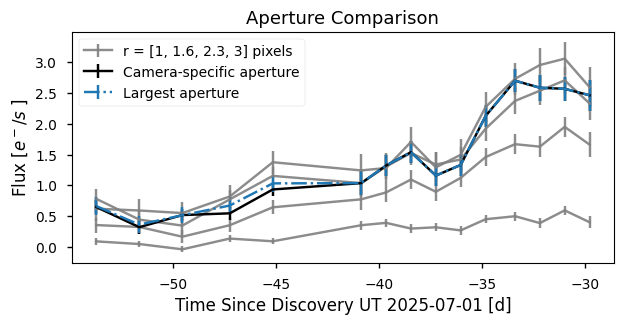

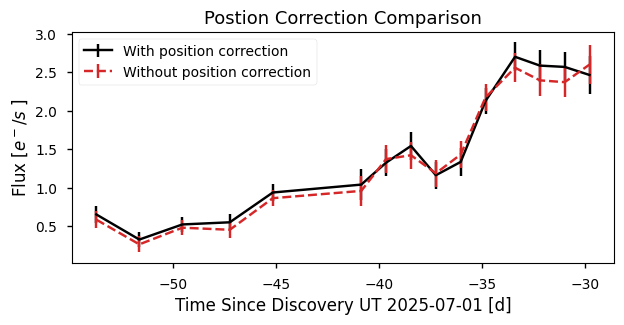

In [ ]:
with plt.style.context('seaborn-v0_8-notebook'):
    fig, ax = plt.subplots(1,1,figsize=(7,3), sharex=True, sharey=True)

    ax.set_title("Aperture Comparison", fontsize=13)
    for size, cir_flx, cir_flx_e in zip(cir_size[1:], phot_try[1:, :, 0], phot_try[1:, :, 1]):
        ax.errorbar(lc.time_utc_geo - discovery_date.jd, cir_flx, yerr=cir_flx_e, c="gray", alpha=0.9, label=f'r = [1, 1.6, 2.3, 3] pixels' if size < 1 else None)
        
    ax.errorbar(lc_corr.time_utc_geo - discovery_date.jd, lc_corr.ap_flux, yerr=lc_corr.ap_flux_err, c="k", label="Camera-specific aperture")
    ax.errorbar(lc_corr.time_utc_geo - discovery_date.jd, phot[1, :, 0], yerr=phot[1, :, 1], c="tab:blue", label="Largest aperture", ls="-.")
    ax.legend()
    ax.set_xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
    ax.set_ylabel("Flux [$e^-/s$ ]", fontsize=12)

    # ax[1].set_title("Postion Correction Comparison", fontsize=13)
    # ax[1].errorbar(lc_corr.time_utc_geo - discovery_date.jd, lc_corr.ap_flux, yerr=lc_corr.ap_flux_err, c="k", label="With position correction")
    # ax[1].errorbar(lc_uncorr.time_utc_geo - discovery_date.jd, lc_uncorr.ap_flux, yerr=lc_uncorr.ap_flux_err, c="tab:red", ls="--", label="Without position correction")
    # ax[1].set_xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
    # ax[1].set_ylabel("Flux [$e^-/s$ ]", fontsize=12)
    # ax[1].legend()

    plt.savefig(
        f"../data/2025/figures/c2025n1_aperture_comp_1.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    
    plt.show()


    fig, ax = plt.subplots(1,1,figsize=(7,3), sharex=True, sharey=True)

    # ax[0].set_title("Aperture Comparison", fontsize=13)
    # for size, cir_flx, cir_flx_e in zip(cir_size[1:], phot_try[1:, :, 0], phot_try[1:, :, 1]):
    #     ax[0].errorbar(lc.time_utc_geo - discovery_date.jd, cir_flx, yerr=cir_flx_e, c="gray", alpha=0.9, label=f'r = [1, 1.6, 2.3, 3] pixels' if size < 1 else None)
        
    # ax[0].errorbar(lc_corr.time_utc_geo - discovery_date.jd, lc_corr.ap_flux, yerr=lc_corr.ap_flux_err, c="k", label="Camera-specific aperture")
    # ax[0].errorbar(lc_corr.time_utc_geo - discovery_date.jd, phot[1, :, 0], yerr=phot[1, :, 1], c="tab:blue", label="Largest aperture", ls="-.")
    # ax[0].legend()
    # ax[0].set_xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
    # ax[0].set_ylabel("Flux [$e^-/s$ ]", fontsize=12)

    ax.set_title("Postion Correction Comparison", fontsize=13)
    ax.errorbar(lc_corr.time_utc_geo - discovery_date.jd, lc_corr.ap_flux, yerr=lc_corr.ap_flux_err, c="k", label="With position correction")
    ax.errorbar(lc_uncorr.time_utc_geo - discovery_date.jd, lc_uncorr.ap_flux, yerr=lc_uncorr.ap_flux_err, c="tab:red", ls="--", label="Without position correction")
    ax.set_xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
    ax.set_ylabel("Flux [$e^-/s$ ]", fontsize=12)
    ax.legend()

    plt.savefig(
        f"../data/2025/figures/c2025n1_aperture_comp_2.pdf", 
        format="pdf", bbox_inches='tight',
    )
    
    plt.show()

In [388]:
np.median(np.abs(lc_uncorr.ap_flux / np.mean(0.9*lc_uncorr.bkg_ap_flux_std)) / np.abs(lc_corr.ap_flux / np.mean(0.9*lc_corr.bkg_ap_flux_std)))

0.9106783798255187

In [447]:
np.diff(d_helio)

array([-0.07050728, -0.07051521, -0.07777061, -0.07047221, -0.14486304,
       -0.04071305, -0.04070448, -0.04069555, -0.04068639, -0.04067698,
       -0.04819864, -0.04057741, -0.04056705, -0.03486349])

# Hv Light Curve

In [135]:
tstart = Time(lc.time_tdb.values[0], scale="utc", format="jd")
tstop  = Time(lc.time_tdb.values[-1], scale="utc", format="jd")

In [136]:
# geo obs
ephems = _get_horizons_ephem("C/2025 N1", start=tstart, stop=tstop, step="6H", location='@TESS').to_pandas()
ephems

,targetname,datetime_str,datetime_jd,M1,solar_presence,k1,interfering_body,RA,DEC,RA_rate,...,Tmag,Nmag,r,r_rate,delta,delta_rate,TDB-UT,alpha_true,PABLon,PABLat
0,ATLAS (C/2025 N1),2025-May-08 12:26:34.314,2.460804e+06,12.3,,4.5,,288.14446,-18.70512,-18.1234,...,19.695,<NA>,6.313182,-58.536494,5.739501,-87.018438,69.185362,7.9192,283.2273,3.5024
1,ATLAS (C/2025 N1),2025-May-08 18:26:34.314,2.460804e+06,12.3,,4.5,,288.11223,-18.70353,-18.4983,...,19.688,<NA>,6.304728,-58.534772,5.726945,-86.854264,69.185358,7.9085,283.2026,3.5057
2,ATLAS (C/2025 N1),2025-May-09 00:26:34.314,2.460805e+06,12.3,,4.5,,288.07936,-18.70187,-18.8448,...,19.681,<NA>,6.296274,-58.533039,5.714415,-86.666737,69.185354,7.8972,283.1775,3.5091
3,ATLAS (C/2025 N1),2025-May-09 06:26:34.314,2.460805e+06,12.3,,4.5,,288.04590,-18.70017,-19.1639,...,19.673,<NA>,6.287820,-58.531295,5.701914,-86.467712,69.185350,7.8855,283.1522,3.5124
4,ATLAS (C/2025 N1),2025-May-09 12:26:34.314,2.460805e+06,12.3,,4.5,,288.01191,-18.69848,-19.4583,...,19.666,<NA>,6.279367,-58.529539,5.689441,-86.264839,69.185346,7.8733,283.1266,3.5159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,ATLAS (C/2025 N1),2025-May-31 06:26:34.314,2.460827e+06,12.3,,4.5,,283.73085,-18.70870,-37.2586,...,18.995,<NA>,5.545112,-58.323332,4.671882,-75.099883,69.184920,5.7798,280.1479,3.7870
92,ATLAS (C/2025 N1),2025-May-31 12:26:34.314,2.460827e+06,12.3,,4.5,,283.66515,-18.71066,-37.3886,...,18.987,<NA>,5.536689,-58.320213,4.661046,-74.976234,69.184914,5.7431,280.1043,3.7897
93,ATLAS (C/2025 N1),2025-May-31 18:26:34.314,2.460827e+06,12.3,,4.5,,283.59924,-18.71275,-37.5074,...,18.979,<NA>,5.528267,-58.317074,4.650226,-74.864488,69.184908,5.7062,280.0605,3.7923
94,ATLAS (C/2025 N1),2025-Jun-01 00:26:34.314,2.460828e+06,12.3,,4.5,,283.53312,-18.71496,-37.6140,...,18.971,<NA>,5.519845,-58.313914,4.639422,-74.767891,69.184903,5.6692,280.0166,3.7948


In [137]:
d_helio = np.interp(lc.time_utc_geo, ephems.datetime_jd, ephems.r)
d_geo = np.interp(lc.time_utc_geo, ephems.datetime_jd, ephems.delta)
vmag = np.interp(lc.time_utc_geo, ephems.datetime_jd, ephems.Tmag)

In [138]:
vmag

array([19.695     , 19.63361825, 19.57221456, 19.50289465, 19.44037966,
       19.30887801, 19.271282  , 19.23268609, 19.19509032, 19.1564947 ,
       19.1184118 , 19.07315519, 19.03463405, 18.99611303, 18.963     ])

In [154]:
Vwoods = lc.prf_mag + 0.671
Vwoods_p = np.sqrt(lc.prf_mag_p.values ** 2)
Vwoods_m = np.sqrt(lc.prf_mag_m.values ** 2)

Vcomet = lc.prf_mag + 0.8
Vcomet_p = np.sqrt(0.3 ** 2 + lc.prf_mag_p.values ** 2)
Vcomet_m = np.sqrt(0.3 ** 2 + lc.prf_mag_m.values ** 2)

In [140]:
Vcomet_p

array([0.39008575, 0.40037173, 0.41947819, 0.37601139, 0.33257415,
       0.35520714, 0.32565647, 0.32724018, 0.32573245, 0.32343434,
       0.3130945 , 0.31004016, 0.31663043, 0.30873257, 0.33179965])

In [141]:
(Vcomet - vmag).mean()

1.517550830316169

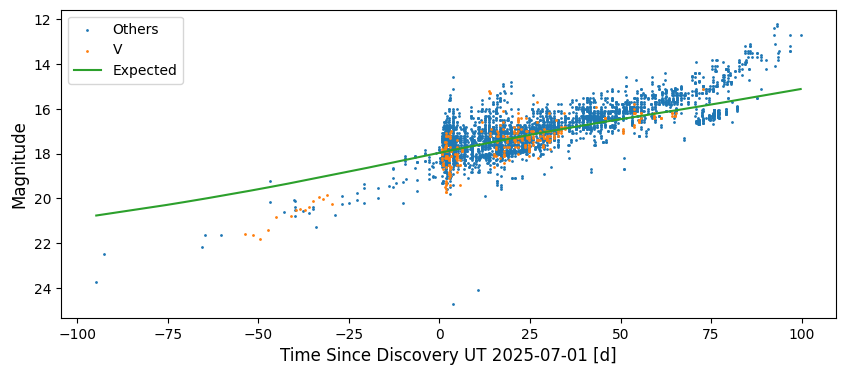

In [142]:
tstart = Time(others_lc.time_utc.values[3], scale="utc", format="jd")
tstop  = Time(others_lc.time_utc.values[-1], scale="utc", format="jd")

# geo obs
ephems = _get_horizons_ephem("C/2025 N1", start=tstart, stop=tstop, step="6H", location='000').to_pandas()
ephems

plt.figure(figsize=(10,4))
plt.scatter(others_lc.query("band != 'V'").time_utc - discovery_date.jd, others_lc.query("band != 'V'").mag, s=1, label="Others")
plt.scatter(others_lc.query("band == 'V'").time_utc - discovery_date.jd, others_lc.query("band == 'V'").mag, s=1, label="V")
plt.plot(ephems.datetime_jd - discovery_date.jd, ephems.Tmag, label="Expected", c="tab:green")
plt.legend()
plt.gca().invert_yaxis()
plt.ylabel("Magnitude", fontsize=12)
plt.xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
plt.show()

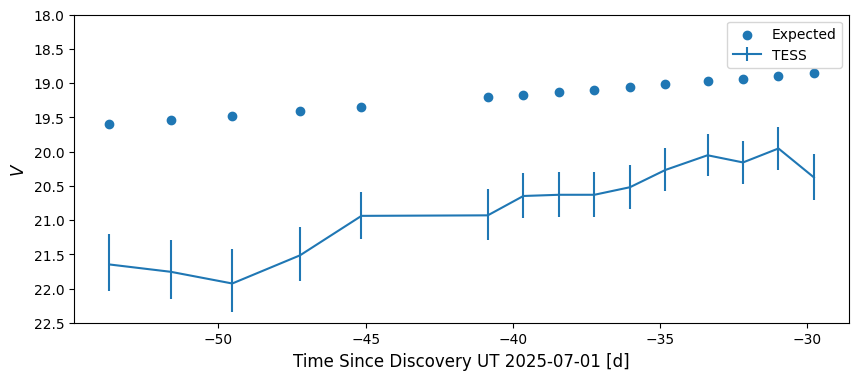

In [143]:
plt.figure(figsize=(10,4))
plt.errorbar(lc.time_utc_geo - discovery_date.jd, Vcomet, yerr=[Vcomet_m, Vcomet_p], label="TESS")
plt.scatter(lc.time_utc_geo - discovery_date.jd, lc.v_mag, label="Expected")
plt.legend()
plt.ylim(22.5, 18)
plt.ylabel("$V$", fontsize=12)
plt.xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
plt.show()

In [147]:
other_r = others_lc.query(f"time_utc >= {lc.time_utc_geo.min()} and time_utc <= {lc.time_utc_geo.max()} and stn != 'C57' and band == 'r' and mag_e > 0")
other_o = others_lc.query(f"time_utc >= {lc.time_utc_geo.min()} and time_utc <= {lc.time_utc_geo.max()} and stn != 'C57' and band == 'Ao'")

In [149]:
Vsun = 4.80
Rsun = 4.60
Bsun = 5.31
g = other_r["mag"] + 1.599*(Vsun-Rsun) - 0.106
V_ztf = -(-1*g + 0.634 * (Bsun-Vsun) - 0.127)
V_ztf_err = np.sqrt(other_r["mag_e"]**2 + 0.009**2 + 0.006**2 + 0.002 ** 2 + 0.002**2)

d_helio_ztf = np.interp(other_r.time_utc, ephems.datetime_jd, ephems.r)
d_geo_ztf = np.interp(other_r.time_utc, ephems.datetime_jd, ephems.delta)

In [222]:
Vcomet_p

array([0.39008575, 0.40037173, 0.41947819, 0.37601139, 0.33257415,
       0.35520714, 0.32565647, 0.32724018, 0.32573245, 0.32343434,
       0.3130945 , 0.31004016, 0.31663043, 0.30873257, 0.33179965])

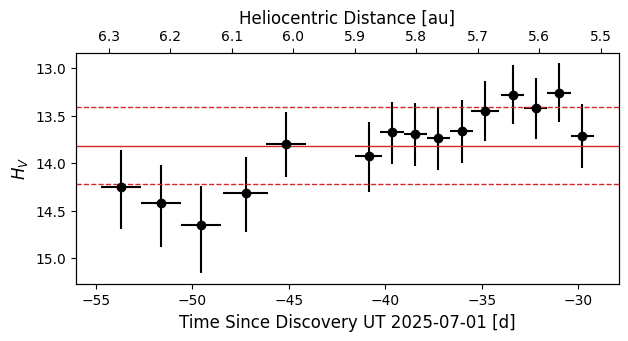

In [ ]:
fig, ax = plt.subplots(figsize=(7,3))

for k1 in [4.5]:
    HV_woods = Vwoods - k1 * np.log10(d_helio) - 5 * np.log10(d_geo)
    HV_comet = Vcomet - k1 * np.log10(d_helio) - 5 * np.log10(d_geo)
    HV_exp = lc.v_mag - k1 * np.log10(d_helio) - 5 * np.log10(d_geo)
    Hv_ztf = V_ztf - k1 * np.log10(d_helio_ztf) - 5 * np.log10(d_geo_ztf)
    # ax.errorbar(lc.time_utc_geo - discovery_date.jd, HV_woods, xerr=lc.time_win/2, yerr=(Vwoods_p, Vwoods_m), fmt="o", label=f"Woods, n={k1/2.5}")
    ax.errorbar(
        lc.time_utc_geo - discovery_date.jd, 
        HV_comet, xerr=lc.time_win/2, 
        yerr=(Vcomet_p, Vcomet_m), 
        fmt="o", c="k", 
        label=f"Farnham, n={k1/2.5}",
    )
    # ax.scatter(other_r.time_utc - discovery_date.jd, Hv_ztf)
    # ax.fill_between(
    #     lc.time_utc_geo - discovery_date.jd,
    #     HV_comet - Vcomet_m, HV_comet + Vcomet_p,
    #     color="gray", alpha=0.2,
    # )
    
    # plt.plot(lc.time_utc_geo - discovery_date.jd, HV_exp, c="gray")
ax.set_ylabel("$H_V$", fontsize=12)
ax.set_xlabel(f"Time Since Discovery UT {discovery_date.iso[:10]} [d]", fontsize=12)
# ax.legend(loc="upper left")

ax.axhline(np.mean(HV_comet), c="tab:red", lw=1)
ax.axhline(np.mean(HV_comet) - np.std(HV_comet), c="tab:red", ls="--", lw=1)
ax.axhline(np.mean(HV_comet) + np.std(HV_comet), c="tab:red", ls="--", lw=1)

axt = ax.twiny()
axt.scatter(d_helio, HV_comet, marker=".", s=0)
axt.invert_yaxis()
axt.invert_xaxis()
axt.set_xlabel(f"Heliocentric Distance [au]", fontsize=12)

plt.savefig(
    f"../data/2025/figures/c2025n1_hv_s{sector:04}.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [159]:
lc["v_mag_exp"] = vmag
lc["T_mag_exp"] = vmag - 0.8
lc["Hv"] = HV_comet
lc["Hv_m"] = Vcomet_m
lc["Hv_p"] = Vcomet_p

NameError: name 'HV_comet' is not defined

In [671]:
print(lc.loc[:, ["time_utc_geo","Hv", "Hv_m", "Hv_p", "T_mag_exp"]].to_latex(index=False, float_format="%.2f"))

\begin{tabular}{rrrrr}
\toprule
time_utc_geo & Hv & Hv_m & Hv_p & T_mag_exp \\
\midrule
2460804.02 & 14.25 & 0.44 & 0.39 & 18.90 \\
2460806.10 & 14.42 & 0.46 & 0.40 & 18.83 \\
2460808.19 & 14.65 & 0.50 & 0.42 & 18.77 \\
2460810.49 & 14.31 & 0.42 & 0.38 & 18.70 \\
2460812.58 & 13.80 & 0.34 & 0.33 & 18.64 \\
2460816.87 & 13.92 & 0.38 & 0.36 & 18.51 \\
2460818.07 & 13.68 & 0.33 & 0.33 & 18.47 \\
2460819.28 & 13.70 & 0.33 & 0.33 & 18.43 \\
2460820.48 & 13.74 & 0.33 & 0.33 & 18.40 \\
2460821.69 & 13.66 & 0.33 & 0.32 & 18.36 \\
2460822.90 & 13.45 & 0.32 & 0.31 & 18.32 \\
2460824.33 & 13.28 & 0.31 & 0.31 & 18.27 \\
2460825.53 & 13.42 & 0.32 & 0.32 & 18.23 \\
2460826.73 & 13.26 & 0.31 & 0.31 & 18.20 \\
2460827.94 & 13.71 & 0.34 & 0.33 & 18.16 \\
\bottomrule
\end{tabular}



# Final LC

In [436]:
lc_final = pd.DataFrame(columns=[
    "time_utc", "time_window", "n_frames", "ra", "dec", 
    "ap_flux", "ap_flux_err", "prf_flux", "prf_flux_err", 
    "ap_mag", "ap_mag_err", "prf_mag", "prf_mag_err",
    "ap_snr", "prf_snr",
    "ra_expected", "dec_expected", "vmag_expected"
])

lc_final["time_utc"] = lc.time_utc_geo.values
lc_final["time_window"] = lc.time_win.values
lc_final["ap_flux"] = lc.ap_flux.values
lc_final["ap_flux_err"] = lc.ap_flux_err.values
lc_final["prf_flux"] = lc.prf_flux.values
lc_final["prf_flux_err"] = lc.prf_flux_err.values
lc_final["ap_mag"] = lc.ap_mag.values
lc_final["ap_mag_err"] = lc.ap_mag_err.values
lc_final["prf_mag"] = lc.prf_mag.values
lc_final["prf_mag_err"] = lc.prf_mag_err.values
lc_final["n_frames"] = lc.nframes.values
lc_final["ra"] = lc.ra_ephem.values - lc.ra_offset/3600
lc_final["dec"] = lc.dec_ephem.values - lc.dec_offset/3600
lc_final["ra_expected"] = lc.ra_ephem.values
lc_final["dec_expected"] = lc.dec_ephem.values
lc_final["ra_offset"] = lc.ra_offset.values
lc_final["dec_offset"] = lc.dec_offset.values
lc_final["vmag_expected"] = lc.v_mag.values
lc_final["ap_snr"] = np.abs(lc.ap_flux / np.mean(lc.empty_flux3))
lc_final["prf_snr"] = np.abs(lc.prf_flux / np.mean(lc.empty_flux3))

lc_final

AttributeError: 'DataFrame' object has no attribute 'empty_flux3'

In [ ]:
# lc_final.to_csv("../data/3i_tess_s0092_time_series.csv")